# 02. Quy trình Tiền xử lý dữ liệu và Thử nghiệm Thiết kế

Notebook này thực hiện các thử nghiệm tiền xử lý dữ liệu dựa trên phản biện kỹ thuật và các đề xuất thiết kế. Dữ liệu được nạp từ thư mục sạch `data_cleaned/` (mỗi mã 1 file CSV riêng, đã reindex theo dòng thời gian chung của toàn thị trường).

## 1. Nạp các thư viện cần thiết

In [1]:
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Thiết lập phong cách hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_CLEANED_DIR = os.path.join("..", "data_cleaned")
print(f"Thư mục data_cleaned: {os.path.abspath(DATA_CLEANED_DIR)}")

Thư mục data_cleaned: C:\Users\USER\Desktop\Stock-VN-forecashing\data_cleaned


## 2. Kiểm chứng Cấu trúc Cột và Thứ tự của Tập dữ liệu đã Làm sạch

In [2]:
sample_files = glob.glob(os.path.join(DATA_CLEANED_DIR, "*.csv"))
required_columns = ['timestamps', 'open', 'high', 'low', 'close', 'volume', 'amount']
verification_failed = False

for fpath in sample_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    
    # Kiểm tra thứ tự và tên cột khớp chính xác yêu cầu
    if list(df.columns) != required_columns:
        print(f"[-] Cổ phiếu {symbol} có thứ tự hoặc tên cột không khớp: {list(df.columns)}")
        verification_failed = True
        break

if not verification_failed:
    print(f"[+] TẤT CẢ các tệp CSV trong data_cleaned/ đều đạt chuẩn thứ tự cột: {required_columns}")

[+] TẤT CẢ các tệp CSV trong data_cleaned/ đều đạt chuẩn thứ tự cột: ['timestamps', 'open', 'high', 'low', 'close', 'volume', 'amount']


## 3. Tạo Cửa Sổ Trượt và Loại Bỏ Cửa Sổ Chứa NaN (Lọc Đình Chỉ Giao Dịch)

Khi nạp dữ liệu từ `data_cleaned/`, các cổ phiếu niêm yết muộn (như SSB) hoặc bị đình chỉ giao dịch lớn hơn 5 phiên sẽ có các dòng chứa `NaN` ở các cột giá. DataLoader sẽ quét và loại bỏ các cửa sổ trượt nếu tỷ lệ chứa NaN vượt quá 10% (hoặc có bất kỳ NaN nào để tránh lỗi PyTorch Tensor).

In [3]:
def extract_windows_with_nan_filter(df, lookback=126, predict=5, max_nan_ratio=0.10):
    """
    Trích xuất các cửa sổ trượt và loại bỏ cửa sổ chứa quá nhiều NaN (> 10% số dòng).
    """
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
    data = df[feature_cols].values
    window_len = lookback + predict
    
    valid_windows = []
    total_windows = len(data) - window_len + 1
    discarded_nan = 0
    
    for i in range(total_windows):
        window_data = data[i : i + window_len]
        
        # Đếm số lượng giá trị NaN trong cửa sổ
        nan_count = np.isnan(window_data).sum()
        total_elements = window_data.size
        nan_ratio = nan_count / total_elements
        
        if nan_ratio > max_nan_ratio:
            discarded_nan += 1
            continue
            
        # Nếu nan_ratio nằm trong khoảng cho phép (<= 10%), chúng ta có thể ffill nốt để tránh lỗi tensor
        if nan_count > 0:
            # Ffill cục bộ trên cửa sổ
            mask = np.isnan(window_data)
            idx = np.where(~mask, np.arange(mask.shape[0])[:, None], 0)
            np.maximum.accumulate(idx, axis=0, out=idx)
            window_data = window_data[idx, np.arange(mask.shape[1])]
            
        valid_windows.append(window_data)
        
    return np.array(valid_windows), discarded_nan, total_windows

# Thử nghiệm trên SSB (niêm yết muộn, chứa nhiều NaN ở giai đoạn đầu)
df_ssb = pd.read_csv(os.path.join(DATA_CLEANED_DIR, "SSB.csv"))
ssb_windows, ssb_discarded, ssb_total = extract_windows_with_nan_filter(df_ssb)
print(f"SSB - Tổng số cửa sổ trượt: {ssb_total}")
print(f"SSB - Số lượng cửa sổ hợp lệ: {ssb_windows.shape[0]}")
print(f"SSB - Số lượng cửa sổ bị hủy do NaN (chưa niêm yết/suspension): {ssb_discarded}")

# Thử nghiệm trên HPG (giao dịch đầy đủ)
df_hpg = pd.read_csv(os.path.join(DATA_CLEANED_DIR, "HPG.csv"))
hpg_windows, hpg_discarded, hpg_total = extract_windows_with_nan_filter(df_hpg)
print(f"\nHPG - Tổng số cửa sổ trượt: {hpg_total}")
print(f"HPG - Số lượng cửa sổ hợp lệ: {hpg_windows.shape[0]}")
print(f"HPG - Số lượng cửa sổ bị hủy do NaN: {hpg_discarded}")

SSB - Tổng số cửa sổ trượt: 1867
SSB - Số lượng cửa sổ hợp lệ: 1194
SSB - Số lượng cửa sổ bị hủy do NaN (chưa niêm yết/suspension): 673

HPG - Tổng số cửa sổ trượt: 1867
HPG - Số lượng cửa sổ hợp lệ: 1867
HPG - Số lượng cửa sổ bị hủy do NaN: 0


## 4. Thử nghiệm Phân phối cột Amount: Tuyến tính Z-score vs Phi Tuyến Log(Amount)

Chúng ta sẽ thực hiện kiểm tra thực chứng xem việc biến đổi `log(amount + 1e-5)` trước khi Z-score có ưu/nhược điểm gì so với Z-score tuyến tính mặc định của Kronos.

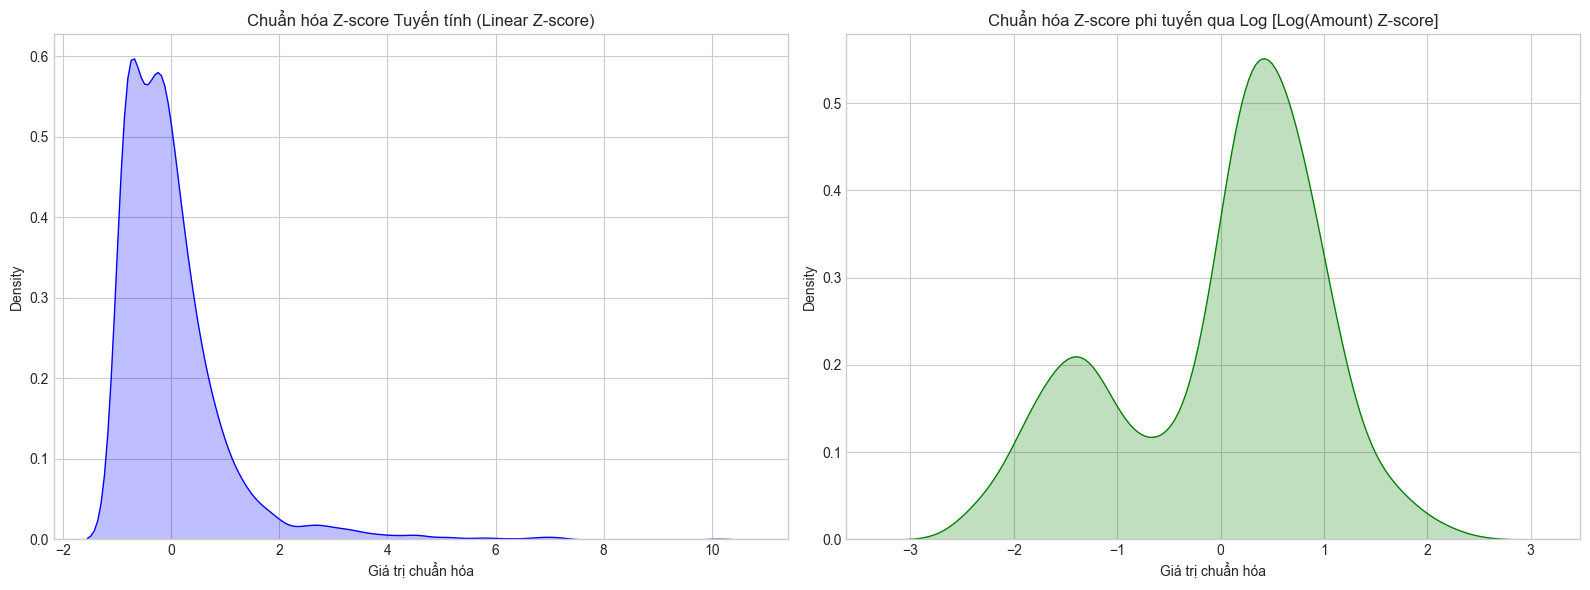

Thống kê phân phối của Amount sau chuẩn hóa:
- Z-score Tuyến tính: Skewness = 3.124, Excess Kurtosis = 16.033
- Z-score qua Log  : Skewness = -0.576, Excess Kurtosis = -0.499

[PHẢN BIỆN KỸ THUẬT]:
Mặc dù biến đổi Log giúp phân phối của Amount gần chuẩn hơn (Skewness gần 0 và Kurtosis nhỏ),
chúng tôi khuyến nghị KHÔNG sử dụng Log(Amount) cho mô hình Kronos fine-tuning vì:
Trọng số pre-trained gốc của Kronos được huấn luyện trên chuỗi chuẩn hóa tuyến tính (Z-score thô).
Việc áp dụng hàm log phi tuyến sẽ thay đổi đặc trưng phân phối đầu vào một cách cơ bản,
gây lệch pha (distribution mismatch) đối với Tokenizer BSQ thô và Predictor đã đóng băng của Kronos.


In [4]:
df_sample = pd.read_csv(os.path.join(DATA_CLEANED_DIR, "HPG.csv"))
amount_raw = df_sample['amount'].values

# 1. Z-score tuyến tính thông thường
mean_raw, std_raw = np.mean(amount_raw), np.std(amount_raw) + 1e-5
z_linear = (amount_raw - mean_raw) / std_raw

# 2. Log-transform trước rồi Z-score
amount_log = np.log(amount_raw + 1e-5)
mean_log, std_log = np.mean(amount_log), np.std(amount_log) + 1e-5
z_log = (amount_log - mean_log) / std_log

# Vẽ đồ thị so sánh phân phối mật độ (KDE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(z_linear, ax=axes[0], fill=True, color='blue')
axes[0].set_title("Chuẩn hóa Z-score Tuyến tính (Linear Z-score)")
axes[0].set_xlabel("Giá trị chuẩn hóa")

sns.kdeplot(z_log, ax=axes[1], fill=True, color='green')
axes[1].set_title("Chuẩn hóa Z-score phi tuyến qua Log [Log(Amount) Z-score]")
axes[1].set_xlabel("Giá trị chuẩn hóa")

plt.tight_layout()
plt.show()

# So sánh skewness và kurtosis
print(f"Thống kê phân phối của Amount sau chuẩn hóa:")
print(f"- Z-score Tuyến tính: Skewness = {stats.skew(z_linear):.3f}, Excess Kurtosis = {stats.kurtosis(z_linear):.3f}")
print(f"- Z-score qua Log  : Skewness = {stats.skew(z_log):.3f}, Excess Kurtosis = {stats.kurtosis(z_log):.3f}")

print("\n[PHẢN BIỆN KỸ THUẬT]:")
print("Mặc dù biến đổi Log giúp phân phối của Amount gần chuẩn hơn (Skewness gần 0 và Kurtosis nhỏ),")
print("chúng tôi khuyến nghị KHÔNG sử dụng Log(Amount) cho mô hình Kronos fine-tuning vì:")
print("Trọng số pre-trained gốc của Kronos được huấn luyện trên chuỗi chuẩn hóa tuyến tính (Z-score thô).")
print("Việc áp dụng hàm log phi tuyến sẽ thay đổi đặc trưng phân phối đầu vào một cách cơ bản,")
print("gây lệch pha (distribution mismatch) đối với Tokenizer BSQ thô và Predictor đã đóng băng của Kronos.")

## 5. Xác minh Tạo Đặc trưng Thời gian (Time Features Check)

Chúng ta thiết lập cố định `minute=0`, `hour=9` cho toàn bộ chuỗi nến Daily, đồng thời trích xuất chính xác các đặc trưng lịch: `weekday`, `day`, `month`.

In [5]:
df_test_time = pd.read_csv(os.path.join(DATA_CLEANED_DIR, "HPG.csv"))
df_test_time['timestamps'] = pd.to_datetime(df_test_time['timestamps'])

# Tạo các đặc trưng thời gian
df_test_time['minute'] = 0
df_test_time['hour'] = 9
df_test_time['weekday'] = df_test_time['timestamps'].dt.weekday
df_test_time['day'] = df_test_time['timestamps'].dt.day
df_test_time['month'] = df_test_time['timestamps'].dt.month

print("5 dòng đầu đặc trưng thời gian:")
display(df_test_time[['timestamps', 'minute', 'hour', 'weekday', 'day', 'month']].head())

# Xác nhận khoảng giá trị
assert (df_test_time['minute'] == 0).all(), "Lỗi: minute phải luôn bằng 0"
assert (df_test_time['hour'] == 9).all(), "Lỗi: hour phải luôn bằng 9"
assert df_test_time['weekday'].between(0, 4).all(), "Lỗi: weekday phải từ 0 đến 4"
assert df_test_time['day'].between(1, 31).all(), "Lỗi: day phải từ 1 đến 31"
assert df_test_time['month'].between(1, 12).all(), "Lỗi: month phải từ 1 đến 12"
print("\n[+] Các đặc trưng thời gian cho nến Daily đã được xác minh chính xác hoàn toàn!")

5 dòng đầu đặc trưng thời gian:


,timestamps,minute,hour,weekday,day,month
0,2018-06-19 09:00:00,0,9,1,19,6
1,2018-06-20 09:00:00,0,9,2,20,6
2,2018-06-21 09:00:00,0,9,3,21,6
3,2018-06-22 09:00:00,0,9,4,22,6
4,2018-06-25 09:00:00,0,9,0,25,6



[+] Các đặc trưng thời gian cho nến Daily đã được xác minh chính xác hoàn toàn!
